# Social Network Analysis — Visualisation

Figures for the Data Structures course project.

**Important:** all graph algorithms (BFS shortest path, mutual-friend
recommendation, connected components) are implemented by hand in C.
NetworkX is used here **only** to draw figures and produce descriptive
statistics for the report — it computes none of the project's features.

Dataset: SNAP `ego-Facebook` (`facebook_combined.txt`), 4039 nodes, 88234 edges.

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import random
from collections import Counter

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

DATA = "../data"      # adjust if your notebook sits elsewhere
OUT  = "../figures"

import os
os.makedirs(OUT, exist_ok=True)

## 1. Load the data

The raw SNAP file is a bare edge list, so `read_edgelist` reads it directly.

In [8]:
G = nx.read_edgelist(f"{DATA}/facebook_combined.txt", nodetype=int)

V = G.number_of_nodes()
E = G.number_of_edges()
print(f"nodes (V) = {V}")
print(f"edges (E) = {E}")

nodes (V) = 4039
edges (E) = 88234


## 2. Density — the sparsity argument

Density is the ratio of actual edges to possible edges:

$$D = \frac{2E}{V(V-1)}$$

This is the number that justifies choosing the adjacency list over the
adjacency matrix. A matrix stores V² cells regardless; the list stores
only what exists.

In [9]:
density = 2 * E / (V * (V - 1))
print(f"density              = {density:.5f}")
print(f"possible edges       = {V*(V-1)//2:,}")
print(f"actual edges         = {E:,}")
print(f"average degree       = {2*E/V:.1f}")
print()

# Memory comparison for the report
matrix_bytes = V * V * 4                 # int matrix
list_bytes   = V * 8 + 2 * E * 16        # head pointers + 2 nodes per edge
print(f"adjacency matrix     ~ {matrix_bytes/1e6:.1f} MB   (O(V^2))")
print(f"adjacency list       ~ {list_bytes/1e6:.1f} MB   (O(V+E))")
print(f"ratio                = {matrix_bytes/list_bytes:.0f}x")

density              = 0.01082
possible edges       = 8,154,741
actual edges         = 88,234
average degree       = 43.7

adjacency matrix     ~ 65.3 MB   (O(V^2))
adjacency list       ~ 2.9 MB   (O(V+E))
ratio                = 23x


## 3. Degree distribution

Most users have few friends; a small number of hubs have hundreds.
The straight-ish line on log-log axes is the signature of a power-law
degree distribution, which is what makes real social graphs sparse.

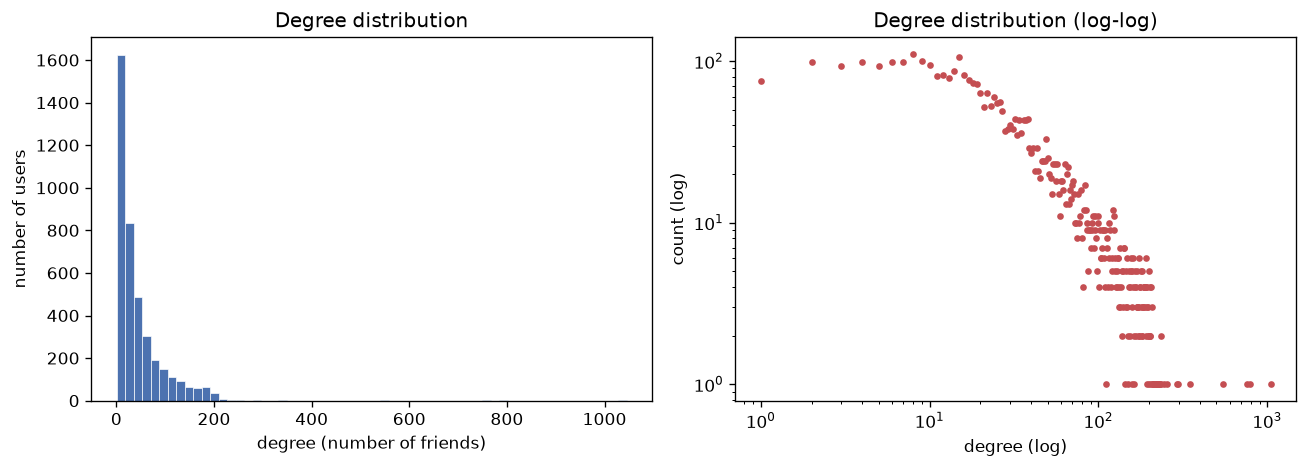

min degree    = 1
max degree    = 1045
mean degree   = 43.7
median degree = 25


In [10]:
degrees = [d for _, d in G.degree()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(degrees, bins=60, color="#4C72B0", edgecolor="white", linewidth=0.4)
ax1.set_xlabel("degree (number of friends)")
ax1.set_ylabel("number of users")
ax1.set_title("Degree distribution")

counts = Counter(degrees)
x = sorted(counts)
y = [counts[k] for k in x]
ax2.loglog(x, y, "o", markersize=3, color="#C44E52")
ax2.set_xlabel("degree (log)")
ax2.set_ylabel("count (log)")
ax2.set_title("Degree distribution (log-log)")

plt.tight_layout()
plt.savefig(f"{OUT}/degree_distribution.png", bbox_inches="tight")
plt.show()

print(f"min degree    = {min(degrees)}")
print(f"max degree    = {max(degrees)}")
print(f"mean degree   = {np.mean(degrees):.1f}")
print(f"median degree = {np.median(degrees):.0f}")

## 4. Path length distribution

Sampling BFS from 200 random sources gives the distribution of shortest
path lengths. Most pairs are 2–5 hops apart — the small-world property.

This is the same computation your C `shortest_path()` performs; here it
is only used to characterise the dataset.

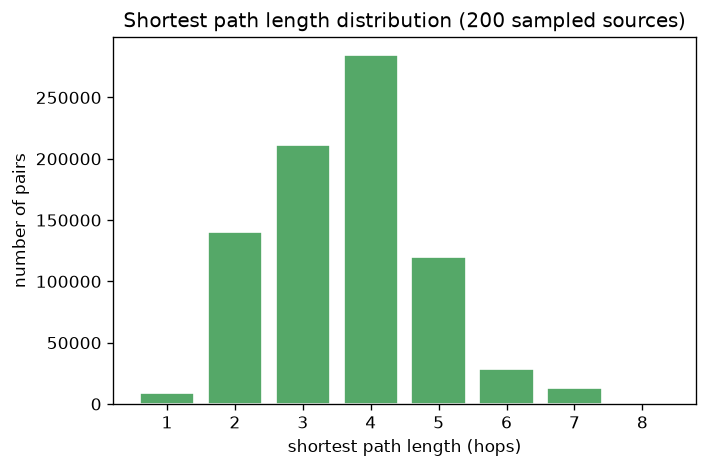

mean path length = 3.63 hops
max observed     = 8 hops


In [11]:
random.seed(42)
sources = random.sample(list(G.nodes()), 200)

lengths = []
for s in sources:
    d = nx.single_source_shortest_path_length(G, s)
    lengths.extend(v for v in d.values() if v > 0)

fig, ax = plt.subplots(figsize=(6, 4))
vals = sorted(set(lengths))
freq = [lengths.count(v) for v in vals]
ax.bar(vals, freq, color="#55A868", edgecolor="white")
ax.set_xlabel("shortest path length (hops)")
ax.set_ylabel("number of pairs")
ax.set_title("Shortest path length distribution (200 sampled sources)")
plt.tight_layout()
plt.savefig(f"{OUT}/path_lengths.png", bbox_inches="tight")
plt.show()

print(f"mean path length = {np.mean(lengths):.2f} hops")
print(f"max observed     = {max(lengths)} hops")

## 5. Full network — all 4039 nodes

The ego-Facebook dataset is ten separate ego networks merged together, so
it does have visible cluster structure and is worth drawing in full.

Two costs to be aware of: `spring_layout` is a force simulation, O(V²) per
iteration, so this cell takes **20–40 seconds**. And individual nodes are
not identifiable at this scale — the figure shows global structure, not
detail. Node size is scaled by degree so the hubs stand out.

layout computed in 19.4s


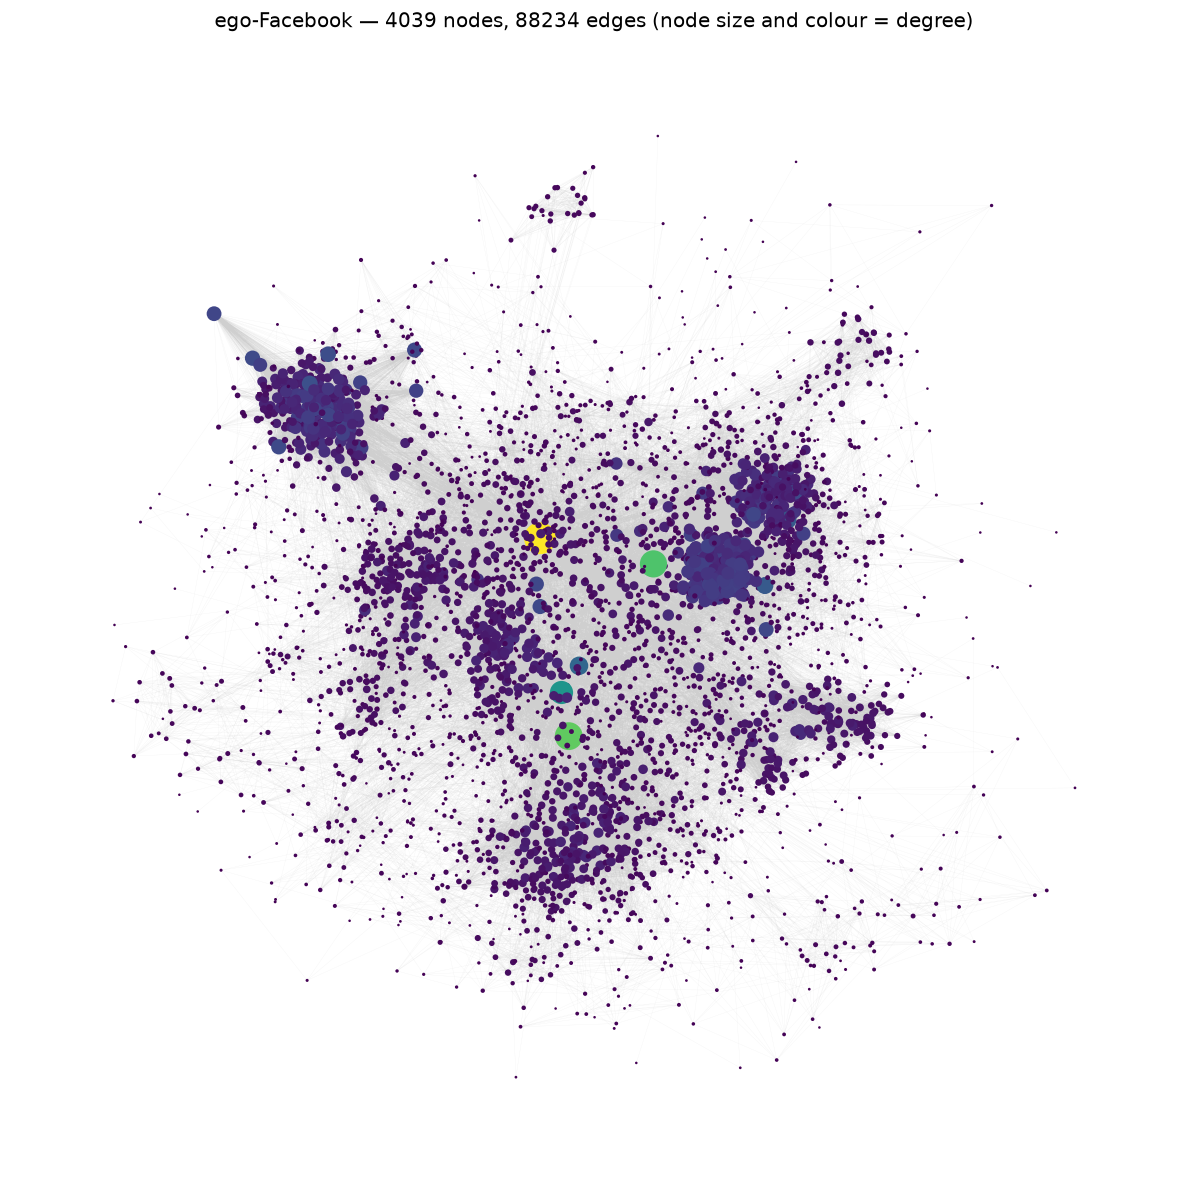

In [12]:
import time

t0 = time.time()
pos_big = nx.spring_layout(G, seed=2, iterations=30)
print(f"layout computed in {time.time()-t0:.1f}s")

deg = dict(G.degree())
sizes = [2 + 0.35 * deg[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(10, 10))
nx.draw_networkx_edges(G, pos_big, ax=ax,
                       edge_color="#cfcfcf", width=0.15, alpha=0.3)
nx.draw_networkx_nodes(G, pos_big, ax=ax, node_size=sizes,
                       node_color=[deg[n] for n in G.nodes()],
                       cmap="viridis", linewidths=0)
ax.set_title(f"ego-Facebook — {V} nodes, {E} edges (node size and colour = degree)")
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUT}/full_network.png", dpi=150, bbox_inches="tight")
plt.show()

### Sampled subgraph — readable version

A 300-node sample of the same graph. Same structure, few enough nodes that
individual vertices and edges can actually be seen.

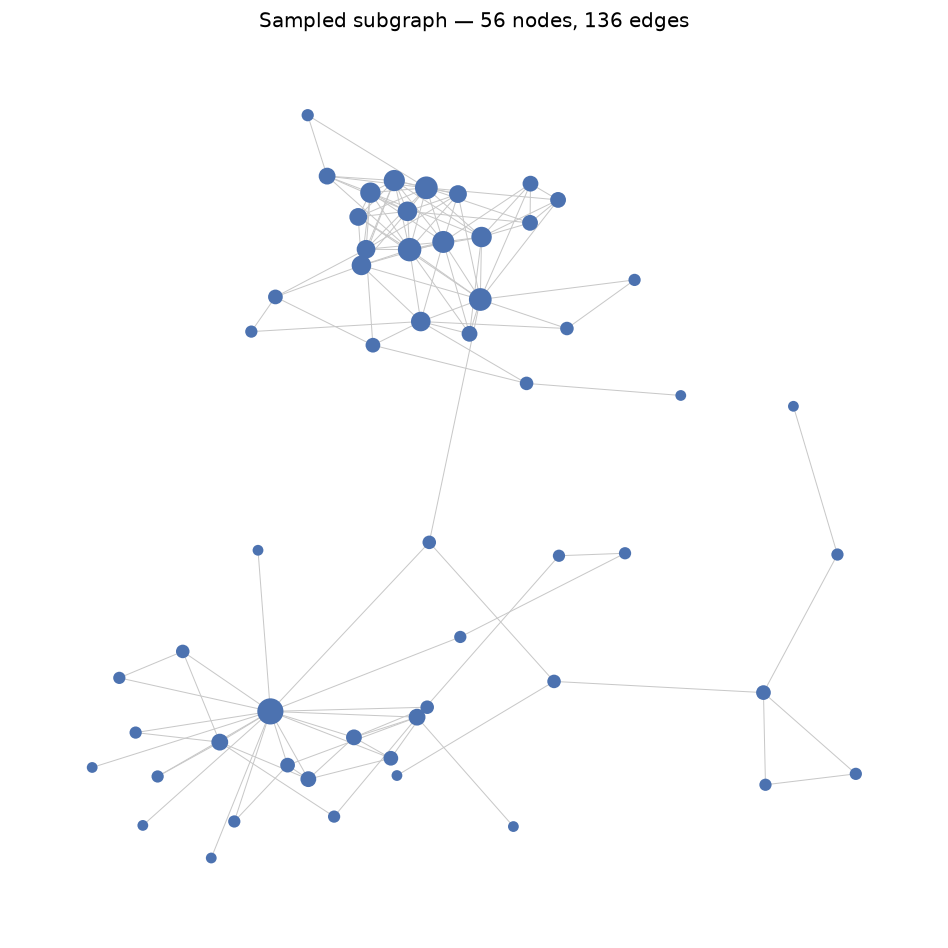

In [13]:
random.seed(11)
sample_nodes = random.sample(list(G.nodes()), 300)
H = G.subgraph(sample_nodes)
H = H.subgraph(max(nx.connected_components(H), key=len))  # largest piece

pos_s = nx.spring_layout(H, seed=5, k=0.35)
deg_s = dict(H.degree())

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw_networkx_edges(H, pos_s, ax=ax, edge_color="#c8c8c8", width=0.6)
nx.draw_networkx_nodes(H, pos_s, ax=ax,
                       node_size=[30 + 12*deg_s[n] for n in H.nodes()],
                       node_color="#4C72B0", linewidths=0)
ax.set_title(f"Sampled subgraph — {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUT}/sampled_network.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. The demo networkThe 4039-node graph cannot be drawn as a node-link diagram — force-directedlayout is O(V²) per iteration and the result is an unreadable hairball.Structure is shown on the small hand-built network instead; the largedataset is characterised statistically above.This cell parses your own `#USERS` / `#EDGES` format.

In [14]:
def load_network(path):
    """Parse the project's own file format into a networkx graph."""
    G = nx.Graph()
    names = {}
    mode = None
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line == "#USERS":
                mode = "users";  continue
            if line == "#EDGES":
                mode = "edges";  continue
            if mode == "users":
                idx, name = line.split(maxsplit=1)
                names[int(idx)] = name
                G.add_node(int(idx))
            elif mode == "edges":
                a, b = line.split()
                G.add_edge(int(a), int(b))
    return G, names

Gd, names = load_network(f"{DATA}/network.txt")
print(f"{Gd.number_of_nodes()} users, {Gd.number_of_edges()} friendships")
print(f"connected components: {nx.number_connected_components(Gd)}")

6 users, 3 friendships
connected components: 3


### Communities coloured, shortest path highlighted

highlighted path: Ayoub -> Omar


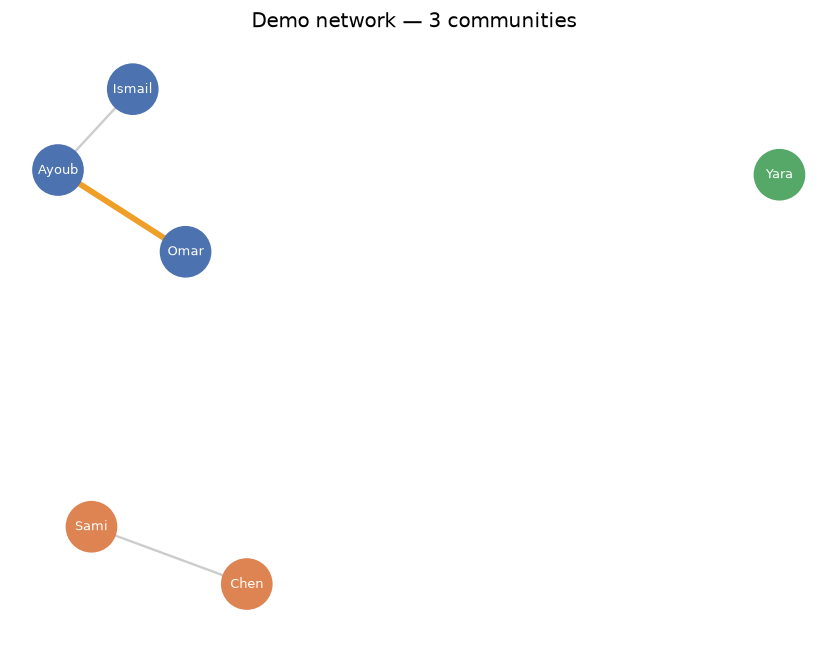

In [15]:
components = list(nx.connected_components(Gd))
palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

color_of = {}
for i, comp in enumerate(components):
    for n in comp:
        color_of[n] = palette[i % len(palette)]

# pick a path to highlight — edit these two names to match your data
SRC_NAME, DST_NAME = "Ayoub", "Omar"
rev = {v: k for k, v in names.items()}

path_edges = []
if SRC_NAME in rev and DST_NAME in rev:
    s, t = rev[SRC_NAME], rev[DST_NAME]
    if nx.has_path(Gd, s, t):
        p = nx.shortest_path(Gd, s, t)
        path_edges = list(zip(p, p[1:]))
        print("highlighted path:", " -> ".join(names[n] for n in p))

pos = nx.spring_layout(Gd, seed=7, k=0.9)

fig, ax = plt.subplots(figsize=(7, 5.5))
nx.draw_networkx_edges(Gd, pos, ax=ax, edge_color="#cccccc", width=1.4)
if path_edges:
    nx.draw_networkx_edges(Gd, pos, edgelist=path_edges, ax=ax,
                           edge_color="#EF9F27", width=3.5)
nx.draw_networkx_nodes(Gd, pos, ax=ax, node_size=900,
                       node_color=[color_of[n] for n in Gd.nodes()])
nx.draw_networkx_labels(Gd, pos, labels=names, ax=ax,
                        font_size=8, font_color="white")
ax.set_title(f"Demo network — {len(components)} communities")
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUT}/demo_network.png", bbox_inches="tight")
plt.show()

## 7. Timing resultsReads `output/timings.csv`, written by the C program, with columns:```nodes,edges,milliseconds```Plotting measured times against V+E shows whether BFS really is linear.**Run the C timing harness first** — this cell does nothing until thatfile exists.

In [16]:
import os

path = "../output/timings.csv"
if not os.path.exists(path):
    print("timings.csv not found — run the C timing harness first.")
else:
    data = np.genfromtxt(path, delimiter=",", names=True)
    nodes, edges, ms = data["nodes"], data["edges"], data["milliseconds"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    ax1.plot(nodes, ms, "o-", color="#4C72B0")
    ax1.set_xlabel("vertices (V)")
    ax1.set_ylabel("time (ms)")
    ax1.set_title("BFS runtime vs graph size")

    ax2.plot(nodes + edges, ms, "o", color="#C44E52", label="measured")
    coef = np.polyfit(nodes + edges, ms, 1)
    xs = np.linspace(min(nodes + edges), max(nodes + edges), 50)
    ax2.plot(xs, np.polyval(coef, xs), "--", color="#888888",
             label=f"linear fit (slope {coef[0]:.2e})")
    ax2.set_xlabel("V + E")
    ax2.set_ylabel("time (ms)")
    ax2.set_title("Runtime vs V + E — linear confirms O(V+E)")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{OUT}/timings.png", bbox_inches="tight")
    plt.show()

timings.csv not found — run the C timing harness first.
